<a href="https://colab.research.google.com/github/Rahma772/Praktikum-Pemodelan-Simulasi-dan-Optimasi/blob/main/Tugas_Praktikum_2_Polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mengimport Library yang akan digunakan**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

**Import Data Berbentuk CSV ke Google Colab**

In [4]:
data = pd.read_csv('/content/data praktikum.csv')
data.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


**Informasi Dataset**

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth      40 non-null     float64
 1   Nporosity  40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


**Menganalisis Statistik Deskriptif**

In [6]:
data.describe()

,Depth,Nporosity
count,40.000000,40.000000
mean,5.125000,0.022250
std,2.922613,0.992111
min,0.250000,-2.080000
25%,2.687500,-0.757500
50%,5.125000,0.140000
75%,7.562500,0.742500
max,10.000000,2.350000


**Membuat Visualisasi Hubungan Variabel**

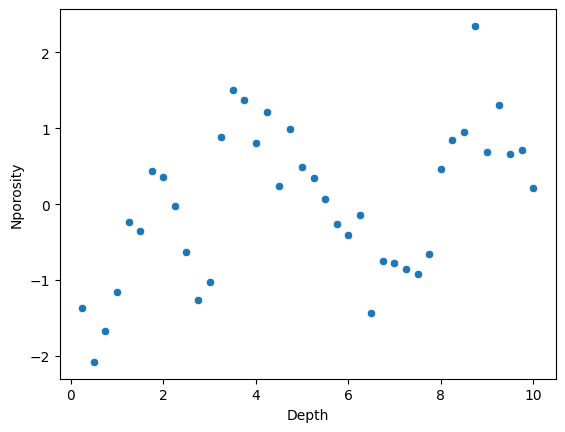

In [7]:
sns.scatterplot(x='Depth', y='Nporosity', data=data)
plt.show()

**Regresi Linear Berganda**

Model Regresi:
Y = β0 + β1X + ε

**Menentukan Variabel**

In [9]:
X = data[['Depth']]
y = data['Nporosity']

**Membuat Model Regresi**

In [10]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

**Melihat Koefisien Model**

In [11]:
print('Intercept:', model.intercept_)
print('Koefisien:', model.coef_)

Intercept: -0.6919615384615387
Koefisien: [0.13935835]


**Prediksi**

In [12]:
y_pred = model.predict(X)
print(y_pred)

[-0.65712195 -0.62228236 -0.58744278 -0.55260319 -0.5177636  -0.48292402
 -0.44808443 -0.41324484 -0.37840525 -0.34356567 -0.30872608 -0.27388649
 -0.2390469  -0.20420732 -0.16936773 -0.13452814 -0.09968856 -0.06484897
 -0.03000938  0.00483021  0.03966979  0.07450938  0.10934897  0.14418856
  0.17902814  0.21386773  0.24870732  0.2835469   0.31838649  0.35322608
  0.38806567  0.42290525  0.45774484  0.49258443  0.52742402  0.5622636
  0.59710319  0.63194278  0.66678236  0.70162195]


**Membuat Visualisasi Hubungan Variabel Orde 1**

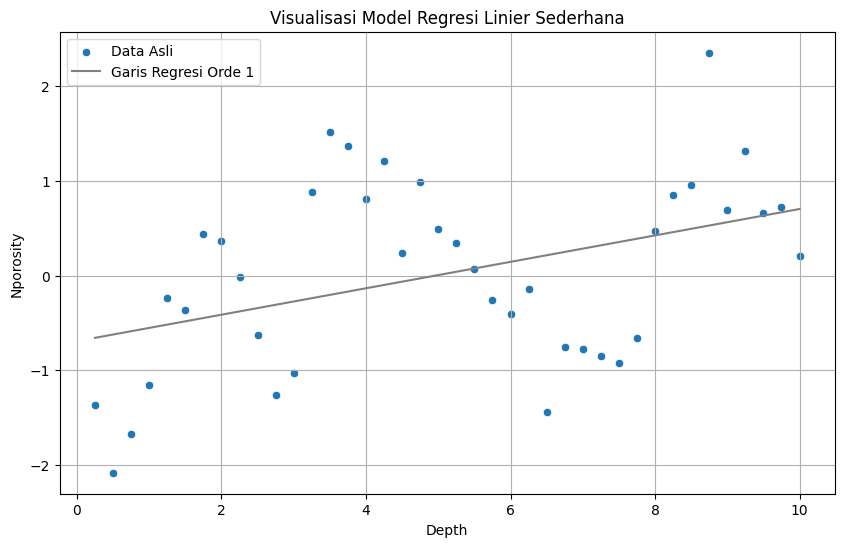

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='grey', label='Garis Regresi Orde 1')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

**Mean Absolute Error (MAE), Mean Squared Error (MSE) dan Root Mean Square Error (RMSE)**

In [16]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))


print('MAE:', mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 0.7399434333958724
MSE: 0.7979390086772984
RMSE: 0.8932743188278158


### Interpretasi
Scatter plot menunjukkan hubungan antara Depth dan Nporosity, di mana titik-titik biru merupakan data asli dan garis menunjukkan garis regresi linier hasil model. Garis yang cenderung naik menunjukkan bahwa semakin besar nilai Depth, maka Nporosity cenderung meningkat. Namun, titik-titik data masih cukup menyebar di sekitar garis regresi sehingga terdapat selisih antara nilai aktual dan nilai prediksi. Hal ini terlihat dari nilai evaluasi model yaitu MAE = 0.7399, MSE = 0.7979, dan RMSE = 0.8933, yang menunjukkan bahwa rata-rata kesalahan prediksi model masih sekitar 0.7 - 0.9 satuan. Penyebaran titik yang tidak tepat pada garis regresi inilah yang menyebabkan nilai error tersebut muncul.


**Regresi Polynomial**

Regresi polynomial merupakan pengembangan dari regresi linier yang digunakan untuk memodelkan hubungan nonlinier antara variabel independen dan variabel dependen. Jika hubungan antara variabel tidak dapat dijelaskan dengan garis lurus, maka regresi polynomial dapat digunakan dengan menambahkan pangkat dari variabel independen ke dalam model.

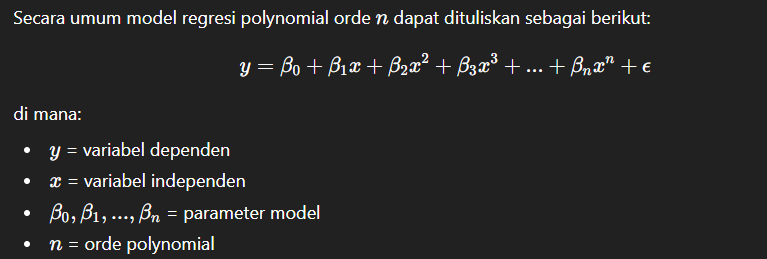


**Membuat Model Orde 2**

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000e+00, 2.50000e-01, 6.25000e-02],
       [1.00000e+00, 5.00000e-01, 2.50000e-01],
       [1.00000e+00, 7.50000e-01, 5.62500e-01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00],
       [1.00000e+00, 1.25000e+00, 1.56250e+00],
       [1.00000e+00, 1.50000e+00, 2.25000e+00],
       [1.00000e+00, 1.75000e+00, 3.06250e+00],
       [1.00000e+00, 2.00000e+00, 4.00000e+00],
       [1.00000e+00, 2.25000e+00, 5.06250e+00],
       [1.00000e+00, 2.50000e+00, 6.25000e+00],
       [1.00000e+00, 2.75000e+00, 7.56250e+00],
       [1.00000e+00, 3.00000e+00, 9.00000e+00],
       [1.00000e+00, 3.25000e+00, 1.05625e+01],
       [1.00000e+00, 3.50000e+00, 1.22500e+01],
       [1.00000e+00, 3.75000e+00, 1.40625e+01],
       [1.00000e+00, 4.00000e+00, 1.60000e+01],
       [1.00000e+00, 4.25000e+00, 1.80625e+01],
       [1.00000e+00, 4.50000e+00, 2.02500e+01],
       [1.00000e+00, 4.75000e+00, 2.25625e+01],
       [1.00000e+00, 5.00000e+00, 2.50000e+01],
       [1.00000e+00, 5.25000e+00, 2.7562

1. Membuat Model Regresi Orde 2

In [18]:
#Membuat model orde 2
model2 = LinearRegression()

model2.fit(X_poly, y)

LinearRegression()

2. Prediksi Model Orde 2

In [19]:
y_pred2 = model2.predict(X_poly)
print(y_pred2)

[-9.52657666e-01 -8.72351045e-01 -7.94437427e-01 -7.18916810e-01
 -6.45789195e-01 -5.75054582e-01 -5.06712970e-01 -4.40764360e-01
 -3.77208752e-01 -3.16046146e-01 -2.57276541e-01 -2.00899939e-01
 -1.46916338e-01 -9.53257381e-02 -4.61281405e-02  6.76455444e-04
  4.50880496e-02  8.71066421e-02  1.26732233e-01  1.63964822e-01
  1.98804409e-01  2.31250995e-01  2.61304578e-01  2.88965160e-01
  3.14232741e-01  3.37107319e-01  3.57588896e-01  3.75677471e-01
  3.91373044e-01  4.04675616e-01  4.15585186e-01  4.24101754e-01
  4.30225321e-01  4.33955885e-01  4.35293448e-01  4.34238009e-01
  4.30789569e-01  4.24948127e-01  4.16713683e-01  4.06086237e-01]


3. Melihat Koefisien Model Orde 2

In [20]:
print('intercept:', model2.intercept_)
print('koefisien:', model2.coef_)

intercept: -1.0353572874493948
koefisien: [ 0.          0.33558449 -0.01914401]


4. Membuat Visualisasi Model Orde 2

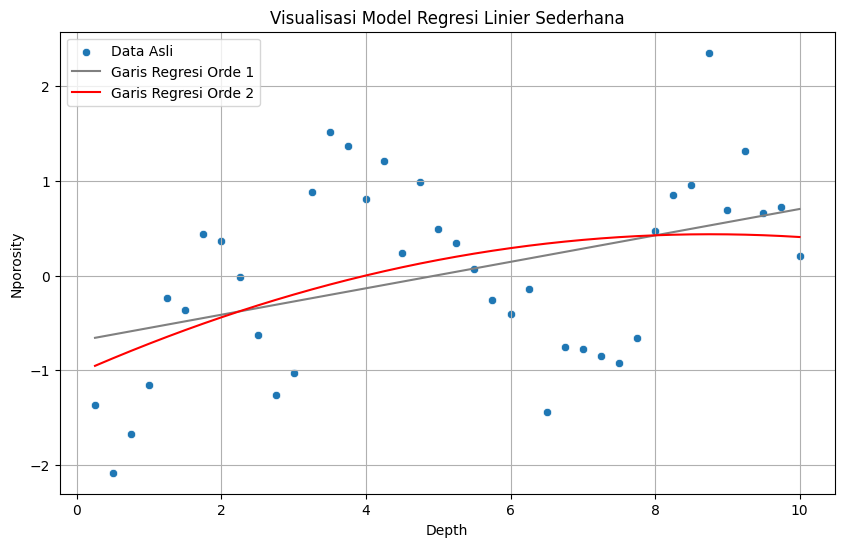

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='grey', label='Garis Regresi Orde 1')
plt.plot(X, y_pred2, color='red', label='Garis Regresi Orde 2')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

5. MAE, MSE, RMSE Orde 2

In [49]:
mae2 = mean_absolute_error(y, y_pred2)
mse2 = mean_squared_error(y, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y, y_pred2))


print('MAE2:', mae2)
print('MSE2:',mse2)
print('RMSE2:',rmse2)

MAE2: 0.7400630834826277
MSE2: 0.7776418670853376
RMSE2: 0.881840046201882


### Interpretasi
Scatterplot yang di hasilkan menunjukkan hubungan antara Depth dan Nporosity dimana garis regresi orde 2 terlihat sedikit lebih mengikuti pola penyebaran data dibandingkan orde 1 yang berbentuk garis lurus, sehingga mampu menangkap sedikit kelengkungan pola data. Namun, masih terdapat beberapa titik yang cukup jauh dari kedua garis tersebut sehingga menimbulkan kesalahan prediksi. Hal ini tercermin pada nilai MAE2 sebesar 0,740, MSE2 sebesar 0,777, dan RMSE2 sebesar 0,882 yang menunjukkan adanya selisih antara nilai prediksi dan nilai sebenarnya.


**Membuat Model Orde 3**

In [23]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01],
       [1.00000000e+00, 2.75000000e+00, 7.56250000e+00, 2.07968750e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01],
       [1.00000000e+00, 3.25000000e+00, 1.05625000e+01, 3.43281250e+01],
       [1.00000000e+00, 3.50000000e+00, 1.22500000e

1. Membuat Model Regresi Orde 3

In [25]:
#Membuat model orde 3
model3 = LinearRegression()

model3.fit(X_poly, y)

LinearRegression()

2. Prediksi Model Orde 3

In [26]:
y_pred3 = model3.predict(X_poly)
print(y_pred3)

[-1.97454493 -1.57981146 -1.22884294 -0.91940306 -0.64925549 -0.41616391
 -0.217892   -0.05220344  0.0831381   0.19036894  0.27172539  0.32944379
  0.36576044  0.38291169  0.38313384  0.36866321  0.34173614  0.30458894
  0.25945793  0.20857944  0.15418979  0.09852529  0.04382228 -0.00768293
 -0.05375402 -0.09215466 -0.12064853 -0.13699931 -0.13897068 -0.12432632
 -0.0908299  -0.0362451   0.0416644   0.14513492  0.27640278  0.43770431
  0.63127582  0.85935364  1.1241741   1.4279735 ]


3. Melihat Koefisien Model

In [27]:
print('intercept:', model3.intercept_)
print('koefisien:', model3.coef_)

intercept: -2.415279680490101
koefisien: [ 0.          1.85792331 -0.3859008   0.0238541 ]


4. Membuat Visualisasi Model Orde 3

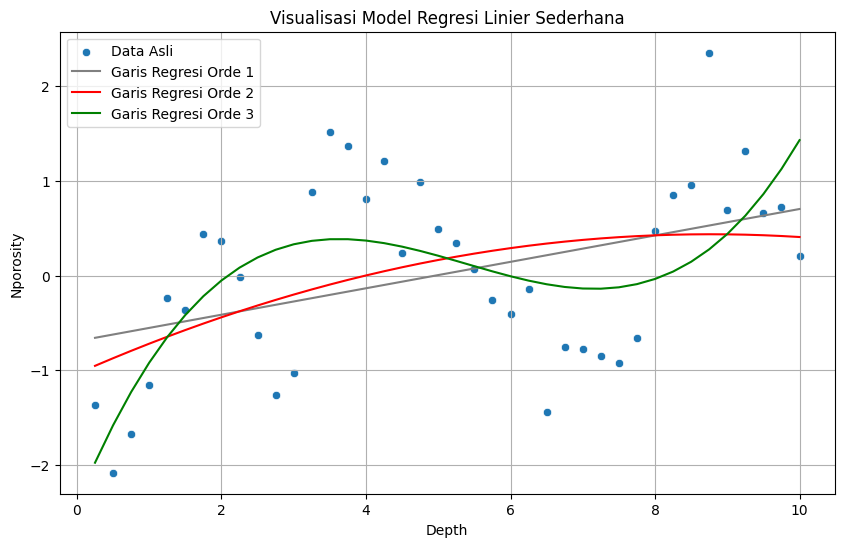

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='grey', label='Garis Regresi Orde 1')
plt.plot(X, y_pred2, color='red', label='Garis Regresi Orde 2')
plt.plot(X, y_pred3, color='green', label='Garis Regresi Orde 3')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

5. MAE, MSE, RMSE Orde 3

In [50]:
mae3 = mean_absolute_error(y, y_pred3)
mse3 = mean_squared_error(y, y_pred3)
rmse3 = np.sqrt(mean_squared_error(y, y_pred3))


print('MAE3:', mae3)
print('MSE3:',mse3)
print('RMSE3:',rmse3)

MAE3: 0.6199845079521994
MSE3: 0.5761954211496901
RMSE3: 0.7590753725090086


### Interpretasi
Scatterplot menunjukkan hubungan antara Depth dan Nporosity, di mana regresi orde 1 hanya membentuk garis lurus sehingga kurang mengikuti pola penyebaran data, sedangkan regresi orde 2 mulai mengikuti pola lengkungan data. Regresi orde 3 terlihat paling menyesuaikan dengan pola titik-titik pada scatterplot karena mampu mengikuti perubahan naik dan turun data. Hal ini juga tercermin dari nilai kesalahan model, yaitu MAE3 = 0,619, MSE3 = 0,576, dan RMSE3 = 0,759 pada orde 3 yang lebih kecil dibandingkan orde sebelumnya, sehingga menunjukkan bahwa model orde 3 memiliki tingkat kesalahan prediksi yang lebih rendah.


**Membuat Model Orde 4**

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01,
        3.90625000e+01],
       [1.00000000e+00, 2.7500

1. Membuat Model Regresi Orde 4

In [31]:
#Membuat model orde 4
model4 = LinearRegression()

model4.fit(X_poly, y)

LinearRegression()

2. Prediksi Model Orde 4

In [32]:
y_pred4 = model4.predict(X_poly)
print(y_pred4)

[-2.21993535 -1.69936064 -1.25235539 -0.87292415 -0.55528031 -0.29384611
 -0.08325262  0.08166025  0.20584375  0.29404028  0.3507834   0.38039785
  0.38699951  0.37449542  0.34658379  0.30675398  0.25828651  0.20425308
  0.14751651  0.09073082  0.03634117 -0.01341613 -0.05651359 -0.09113256
 -0.11566325 -0.12870471 -0.1290648  -0.11576025 -0.08801661 -0.0452683
  0.01284145  0.08646055  0.17552809  0.27977431  0.39872059  0.53167949
  0.67775474  0.8358412   1.00462492  1.18258308]


3. Melihat Koefisien Model Orde 4

In [33]:
print('intercept:', model4.intercept_)
print('koefisien:', model4.coef_)

intercept: -2.820283811139648
koefisien: [ 0.00000000e+00  2.56942257e+00 -6.89355799e-01  6.95205274e-02
 -2.22763062e-03]


4. Membuat Visualisasi Model Orde 4

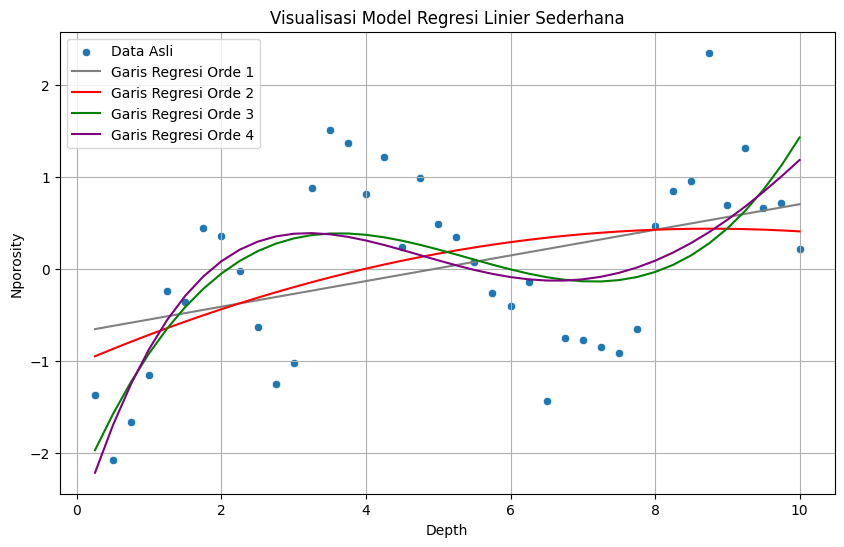

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='grey', label='Garis Regresi Orde 1')
plt.plot(X, y_pred2, color='red', label='Garis Regresi Orde 2')
plt.plot(X, y_pred3, color='green', label='Garis Regresi Orde 3')
plt.plot(X, y_pred4, color='purple', label='Garis Regresi Orde 4')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

5. MAE, MSE, RMSE Orde 4

In [53]:
mae4 = mean_absolute_error(y, y_pred4)
mse4 = mean_squared_error(y, y_pred4)
rmse4 = np.sqrt(mean_squared_error(y, y_pred4))


print('MAE4:', mae4)
print('MSE4:',mse4)
print('RMSE4:',rmse4)

MAE4: 0.6104172796114554
MSE4: 0.565152739676581
RMSE4: 0.751766412974523


### Interpretasi
Scatterplot menunjukkan hubungan antara Depth dan Nporosity, di mana regresi orde 1 hanya membentuk garis lurus sehingga kurang mampu mengikuti pola penyebaran data, sedangkan orde 2 mulai menunjukkan pola lengkungan yang lebih mendekati sebaran titik. Regresi orde 3 dan orde 4 terlihat lebih fleksibel dalam mengikuti naik-turunnya pola data pada scatterplot. Hal ini tercermin dari nilai error model pada orde 4 yaitu MAE4 = 0,610, MSE4 = 0,565, dan RMSE4 = 0,752, yang lebih kecil dibandingkan orde sebelumnya, sehingga menunjukkan bahwa model orde 4 memiliki kesalahan prediksi paling rendah.


**Membuat Model Orde 5**

In [36]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03, 9.76562500e-04],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02, 3.12500000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01, 2.37304688e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00, 3.05175781e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00, 7.59375000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00, 1.64130859e+01],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01, 3.20000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01, 

1. Membuat Model Regresi Orde 5

In [37]:
#Membuat model orde 5
model5 = LinearRegression()

model5.fit(X_poly, y)

LinearRegression()

2. Prediksi Model Orde 5

In [38]:
y_pred5 = model5.predict(X_poly)
print(y_pred5)

[-1.32620662 -1.49311555 -1.48031049 -1.33655998 -1.10399591 -0.81850468
 -0.51011835 -0.20340586  0.08213581  0.33169052  0.53473173  0.68463137
  0.77826865  0.8156389   0.79946241  0.73479322  0.62862798  0.48951478
  0.32716195  0.15204693 -0.02497494 -0.19306157 -0.34177529 -0.46147403
 -0.5437025  -0.58158333 -0.57020828 -0.50702938 -0.39225013 -0.22921663
 -0.02480879  0.21016849  0.46059421  0.70664004  0.92337915  1.0803951
  1.14139057  1.0637963   0.79837983  0.28885435]


3. Melihat Koefisien Orde 5

In [57]:
print('intercept:', model5.intercept_)
print('koefisien:', model5.coef_)

intercept: -0.9237873399842297
koefisien: [ 0.         -2.16243376  2.38459902 -0.71490841  0.0833085  -0.003338  ]


4. Membuat Visualisasi Model

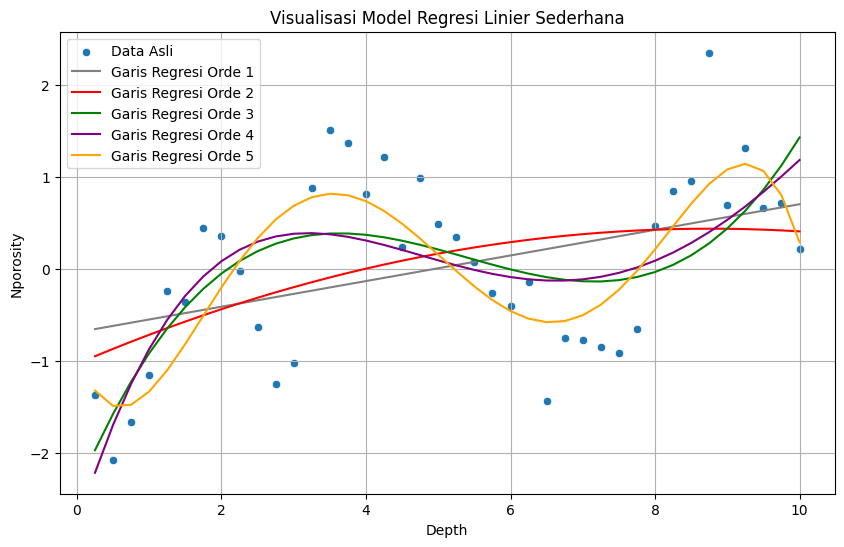

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='grey', label='Garis Regresi Orde 1')
plt.plot(X, y_pred2, color='red', label='Garis Regresi Orde 2')
plt.plot(X, y_pred3, color='green', label='Garis Regresi Orde 3')
plt.plot(X, y_pred4, color='purple', label='Garis Regresi Orde 4')
plt.plot(X, y_pred5, color='orange', label='Garis Regresi Orde 5')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

5. MAE, MEAN, DAN RMSE Orde 5

In [59]:
mae5 = mean_absolute_error(y, y_pred5)
mse5 = mean_squared_error(y, y_pred5)
rmse5 = np.sqrt(mean_squared_error(y, y_pred5))


print('MAE5:', mae5)
print('MSE5:',mse5)
print('RMSE5:',rmse5)

MAE5: 0.4844700295770121
MSE5: 0.4110660686255764
RMSE5: 0.641144343050437


### Interpretasi
Scatterplot menunjukkan hubungan antara Depth dan Nporosity, di mana regresi orde 1 hanya membentuk garis lurus sehingga kurang mampu mengikuti pola penyebaran data, sedangkan orde 2 mulai memperlihatkan sedikit kelengkungan. Regresi orde 3 dan orde 4 semakin mampu mengikuti pola naik turun titik pada scatterplot, sementara regresi orde 5 terlihat paling mendekati pola penyebaran data dibandingkan orde sebelumnya. Hal ini juga terlihat dari nilai kesalahan model yang semakin kecil, yaitu MAE5 = 0,484, MSE5 = 0,411, dan RMSE5 = 0,641 pada orde 5, yang menunjukkan bahwa rata-rata selisih antara nilai prediksi dan nilai sebenarnya semakin kecil. Maka dapat di simpulkan, semakin tinggi orde regresi maka garis model semakin mengikuti pola titik pada scatterplot sehingga nilai MAE, MSE, dan RMSE menjadi lebih rendah dan model prediksi menjadi lebih akurat.
